# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [ ]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


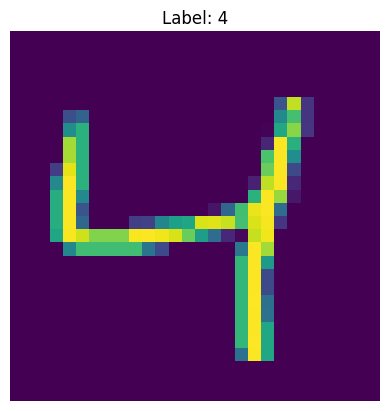

In [ ]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [ ]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [ ]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [ ]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [ ]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.2121894657611847  Accuracy: 96.26386260986328 %
Iteration: 1000  Loss: 0.024657219648361206  Accuracy: 97.17843627929688 %
Iteration: 1500  Loss: 0.06790795177221298  Accuracy: 97.47032165527344 %
Iteration: 2000  Loss: 0.15658722817897797  Accuracy: 97.7232894897461 %
Iteration: 2500  Loss: 0.036171529442071915  Accuracy: 97.85950469970703 %
Iteration: 3000  Loss: 0.053209513425827026  Accuracy: 98.01517486572266 %
Iteration: 3500  Loss: 0.010474886745214462  Accuracy: 98.30706024169922 %
Iteration: 4000  Loss: 0.03672320023179054  Accuracy: 98.36544036865234 %
Iteration: 4500  Loss: 0.11321907490491867  Accuracy: 98.54057312011719 %


#### **ANN 학습 결과**

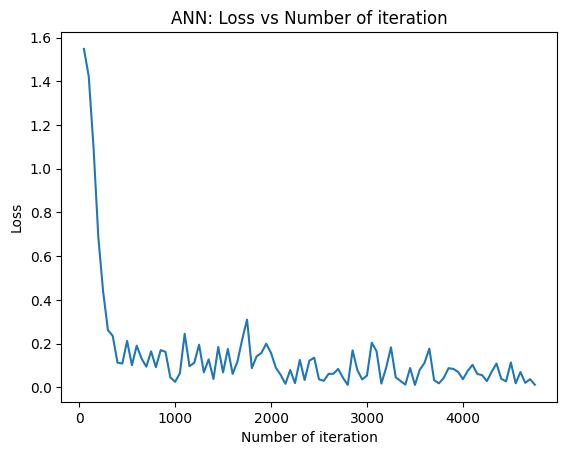

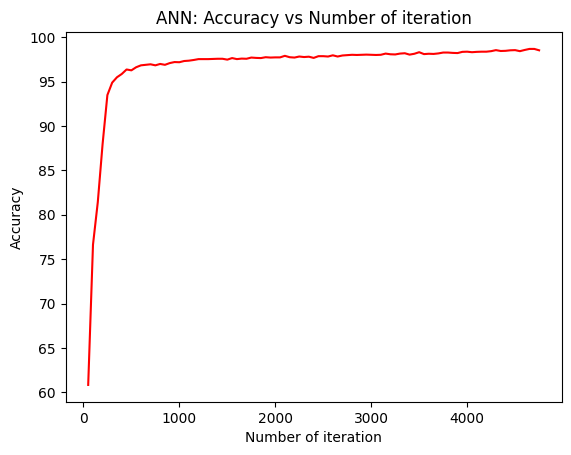

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

**1. Loss 시각화 해석**

처음에 손실 값이 약 1.5 이상으로 시작했다.

약 500 iteration 이내에서 손실 값이 급격히 줄어드는데, 학습률이 적절하고 모델이 패턴을 잘 학습한다는 것을 알 수 있다.

이후 0.1 부근에서 안정적으로 수렴하지만 약간의 변동(노이즈)이 있었다. 데이터 일부만 보고 기울기를 계산하여 샘플 구성에 따라 기울기 값이 조금씩 달라지는 미니배치 SGD의 특성상 손실 값이 완전히 평평하지 않고 출렁이게 된다.

결론적으로 모델이 빠르고 안정적으로 학습에 성공했고, 과적합 징후는 크게 보이지 않는다.

**2. Accuracy 시각화 해석**

처음에 정확도가 60% 수준에서 시작다.

1000 iteration 이전에 약 96%까지 도달한 것을 보아 모델이 기본적인 숫자 특징을 잘 구분하기 시작했음을 알 수 있다.

이후 97~99% 구간에서 점차 수렴했고, 더 많은 반복에서 크게 상승하지 않음

결론적으로 모델이 거의 완벽에 가까운 성능을 달성했으며, 추가 학습은 큰 성능 향상을 가져오지 않았다.

---
**-->**


최종적으로, Loss는 거의 0에 가까워졌고 Accuracy는 98~99% 근처에 도달했다.

따라서 학습이 안정적으로 진행되었고 적절한 수렴을 보여주었다는 것을 알 수 있다.

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [ ]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
hidden_dims = [50, 100, 150, 200]

results = {}

# hidden_dim 별 실험
for h in hidden_dims:
    print(f"\n===== Hidden Dim: {h} =====")

    model = ANNModel(input_dim, h, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []

    for epoch in range(10):
        for i, (images, labels) in enumerate(train_loader):

            # 데이터를 모델 입력 형태로 변환
            train = images.view(-1, 28*28)
            labels = labels

            # 옵티마이저 초기화
            optimizer.zero_grad()

            # Forward
            outputs = model(train)

            # 손실 계산
            loss = loss_ftn(outputs, labels)

            # Backward
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0

                # 테스트 데이터셋 정확도 계산
                for images, labels in test_loader:
                    test = images.view(-1, 28*28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()

                accuracy = 100 * correct / float(total)

                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

            if count % 500 == 0:
                print(f"Iteration: {count}  Loss: {loss.item():.4f}  Accuracy: {accuracy:.2f} %")

    # 결과 저장
    results[h] = {
        "loss": loss_list,
        "iteration": iteration_list,
        "accuracy": accuracy_list
    }


===== Hidden Dim: 50 =====
Iteration: 500  Loss: 0.2251  Accuracy: 95.95 %
Iteration: 1000  Loss: 0.2176  Accuracy: 97.00 %
Iteration: 1500  Loss: 0.0661  Accuracy: 97.51 %
Iteration: 2000  Loss: 0.2240  Accuracy: 97.66 %
Iteration: 2500  Loss: 0.0236  Accuracy: 97.72 %
Iteration: 3000  Loss: 0.0178  Accuracy: 98.02 %
Iteration: 3500  Loss: 0.1063  Accuracy: 98.09 %
Iteration: 4000  Loss: 0.0421  Accuracy: 98.17 %
Iteration: 4500  Loss: 0.0489  Accuracy: 98.33 %

===== Hidden Dim: 100 =====
Iteration: 500  Loss: 0.2226  Accuracy: 96.26 %
Iteration: 1000  Loss: 0.0602  Accuracy: 97.24 %
Iteration: 1500  Loss: 0.0509  Accuracy: 97.37 %
Iteration: 2000  Loss: 0.0682  Accuracy: 97.65 %
Iteration: 2500  Loss: 0.0824  Accuracy: 97.76 %
Iteration: 3000  Loss: 0.0867  Accuracy: 97.94 %
Iteration: 3500  Loss: 0.0468  Accuracy: 98.21 %
Iteration: 4000  Loss: 0.0141  Accuracy: 98.09 %
Iteration: 4500  Loss: 0.0144  Accuracy: 98.37 %

===== Hidden Dim: 150 =====
Iteration: 500  Loss: 0.3072  Accu

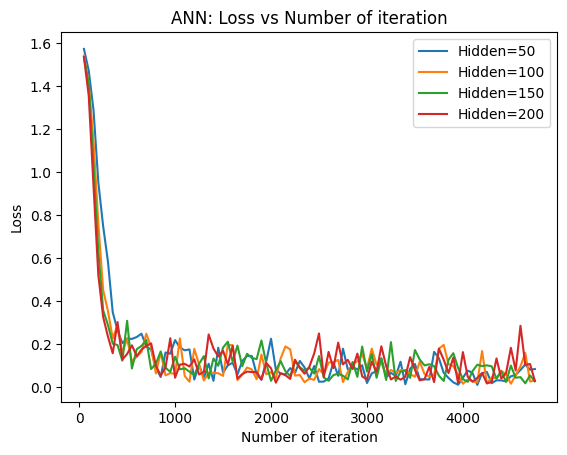

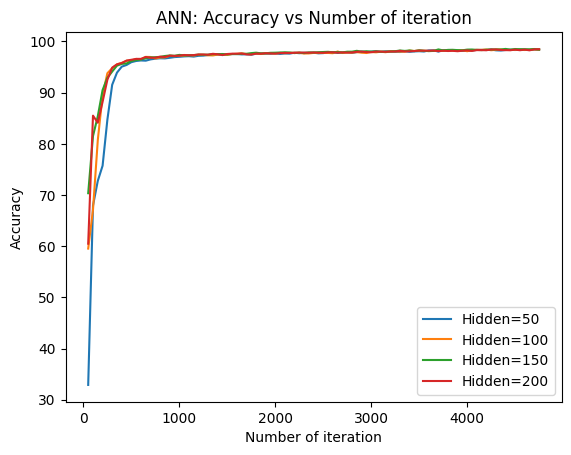

In [ ]:
# 실험 1 모델 학습 결과 시각화
# Loss 시각화
for h in hidden_dims:
    plt.plot(results[h]["iteration"], results[h]["loss"], label=f"Hidden={h}")
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.legend()
plt.show()

# Accuracy 시각화
for h in hidden_dims:
    plt.plot(results[h]["iteration"], results[h]["accuracy"], label=f"Hidden={h}")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.legend()
plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗


---
**[답변]**

**1. Loss 시각화 해석**

모든 hidden dimension 값(50, 100, 150, 200)에서 처음엔 손실이 크게 시작하고 이후 빠르게 감소했다.

일정 iteration 이후에는 거의 0에 가까운 값으로 수렴했다.

hidden_dim이 커질수록 손실 곡선의 진동(노이즈)이 약간 커지는 경우가 있었지만, 큰 차이는 없었다.

결론적으로 hidden dimension의 크기가 커져도 학습 안정성이나 최종 손실 값에는 큰 차이가 없었다.

**2. Accuracy 곡선 해석**

초기 학습에 있어서 hidden dimension 값이 50인 경우에는 약간 느리게 올라가지만, 곧 다른 모델과 비슷한 정확도에 도달했다.

일정 iteration 이후에 모든 hidden dimension 값에서 정확도가 98~99%로 수렴했다.

hidden dimension 값 100, 150, 200은 거의 차이가 없으며, 50도 결국 같은 성능에 도달.

결론적으로 hidden dimension 값이 크다고 해서 정확도가 크게 개선되지는 않았고,  오히려 hidden dimension 값 50만으로도 충분히 높은 정확도 확보가 가능했다.

---
**-->**

hidden dimension 값이 50인 경우도 최종 성능은 충분히 좋지만, 학습 초기 속도가 상대적으로 느렸다. 또, hidden dimension 값을 150~200으로 늘려도 성능이 크게 향상되지 않았다.

따라서 hidden dimension 값이 100인 경우가 제일 최적이라는 것을 알 수 있다.


In [ ]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
# 실험할 learning rate 값
learning_rates = [0.1, 0.05, 0.02, 0.01, 0.005]

results_lr = {}

# learning_rate 별 실험
for lr in learning_rates:
    print(f"\n===== Learning Rate: {lr} =====")

    model = ANNModel(input_dim, hidden_dim, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []

    for epoch in range(10):
        for i, (images, labels) in enumerate(train_loader):

            # 데이터 변환
            train = images.view(-1, 28*28)
            labels = labels

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)

            loss.backward()
            optimizer.step()

            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0

                # 테스트 정확도 계산
                for images, labels in test_loader:
                    test = images.view(-1, 28*28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()

                accuracy = 100 * correct / float(total)

                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

            if count % 500 == 0:
                print(f"Iteration: {count}  Loss: {loss.item():.4f}  Accuracy: {accuracy:.2f} %")

    # 결과 저장
    results_lr[lr] = {
        "loss": loss_list,
        "iteration": iteration_list,
        "accuracy": accuracy_list
    }


===== Learning Rate: 0.1 =====
Iteration: 500  Loss: 0.0165  Accuracy: 97.51 %
Iteration: 1000  Loss: 0.0608  Accuracy: 98.31 %
Iteration: 1500  Loss: 0.1037  Accuracy: 98.81 %
Iteration: 2000  Loss: 0.0150  Accuracy: 98.89 %
Iteration: 2500  Loss: 0.0317  Accuracy: 99.07 %
Iteration: 3000  Loss: 0.0047  Accuracy: 99.28 %
Iteration: 3500  Loss: 0.0020  Accuracy: 99.36 %
Iteration: 4000  Loss: 0.0178  Accuracy: 99.32 %
Iteration: 4500  Loss: 0.0003  Accuracy: 99.34 %

===== Learning Rate: 0.05 =====
Iteration: 500  Loss: 0.1297  Accuracy: 97.18 %
Iteration: 1000  Loss: 0.1969  Accuracy: 97.74 %
Iteration: 1500  Loss: 0.0208  Accuracy: 98.19 %
Iteration: 2000  Loss: 0.0093  Accuracy: 98.52 %
Iteration: 2500  Loss: 0.0169  Accuracy: 98.66 %
Iteration: 3000  Loss: 0.0567  Accuracy: 98.87 %
Iteration: 3500  Loss: 0.0500  Accuracy: 99.12 %
Iteration: 4000  Loss: 0.0320  Accuracy: 99.07 %
Iteration: 4500  Loss: 0.0060  Accuracy: 99.12 %

===== Learning Rate: 0.02 =====
Iteration: 500  Loss: 

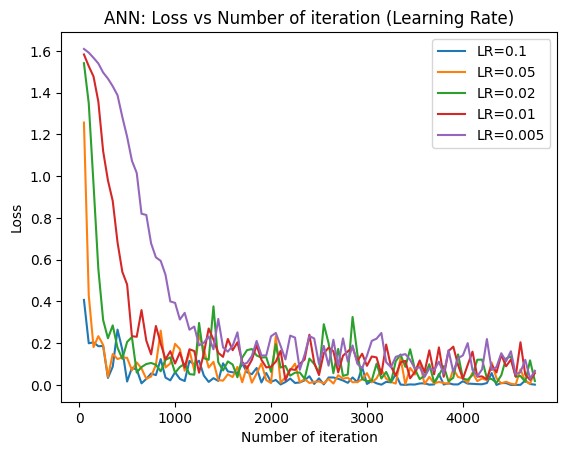

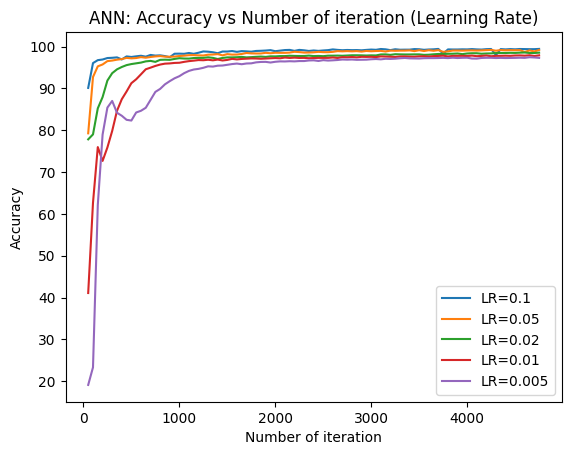

In [ ]:
# 실험 2 모델 학습 결과 시각화
# Loss 비교
for lr in learning_rates:
    plt.plot(results_lr[lr]["iteration"], results_lr[lr]["loss"], label=f"LR={lr}")
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration (Learning Rate)")
plt.legend()
plt.show()

# Accuracy 비교
for lr in learning_rates:
    plt.plot(results_lr[lr]["iteration"], results_lr[lr]["accuracy"], label=f"LR={lr}")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration (Learning Rate)")
plt.legend()
plt.show()


**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

**1. Loss 곡선 해석**

LR(learning rate)=0.1 (파란색): 손실이 매우 빠르게 줄어들었다. 하지만 곡선이 요동치며 불안정한 구간도 존재해 학습 속도는 빠르지만 모델이 최적점을 넘어 튀어다니며 불안정하게 학습되는 overshooting의 위험이 있다.

LR=0.05, 0.02 (주황/초록색): 손실이 빠르고 안정적으로 감소했고, 진동도 크지 않고 적절히 수렴했다.

LR=0.01 (빨강): 감소 속도가 상대적으로 느리지만 안정적으로 수렴했다.

LR=0.005 (보라): 손실 감소가 가장 느리고, 수렴까지 오래 걸렸다.

결론적으로 LR이 너무 크면 불안정하고 너무 작으면 수렴이 너무 느려지는 것을 알 수 있다.

**2. Accuracy 곡선 해석**

LR=0.1: 정확도가 아주 빠르게 98% 부근에 도달하지만, 중간에 진동이 있어 안정성이 다소 떨어진다.

LR=0.05, 0.02: 정확도가 빠르게 상승하고 안정적으로 99% 근처에 수렴했다.

LR=0.01: 상승 속도가 다소 느리지만 최종적으로는 높은 정확도에 도달했다.

LR=0.005: 정확도가 가장 늦게 올라가며, 초반 정확도가 낮았다. 최종적으로도 약간 낮은 수준에서 수렴했다.

결론적으로 0.02 ~ 0.05 구간이 가장 안정적이고 빠르게 높은 정확도에 수렴했다.


---
**-->**

learning rate가 0.1인 경우는 불안정하고, 0.005인 경우는 너무 느려서 비효율적이었다.

따라서 빠른 학습과 안정적인 수렴을 보여주는 0.02~0.05의 learning rate가 최적값이라는 것을 알 수 있다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [ ]:
# CNN 객체 생성
model = CNNModel()

# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [ ]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.5576983506349936
Epoch 2, Loss: 0.1253776803324952
Epoch 3, Loss: 0.1034883499934896
Epoch 4, Loss: 0.08705828681156537
Epoch 5, Loss: 0.0761005812118487
Epoch 6, Loss: 0.06765078170330016
Epoch 7, Loss: 0.060216308300167574
Epoch 8, Loss: 0.05491544577654739
Epoch 9, Loss: 0.05103438352147168
Epoch 10, Loss: 0.04713558136740221
Epoch 11, Loss: 0.04291544498662836
Epoch 12, Loss: 0.040278502317079364
Epoch 13, Loss: 0.038192024325664174
Epoch 14, Loss: 0.03579698590268157
Epoch 15, Loss: 0.03384510316037318
Epoch 16, Loss: 0.032134063654658936
Epoch 17, Loss: 0.03075719994898946
Epoch 18, Loss: 0.029496770989857535
Epoch 19, Loss: 0.028441689638975066
Epoch 20, Loss: 0.026931449751970447


#### **CNN 학습 결과**

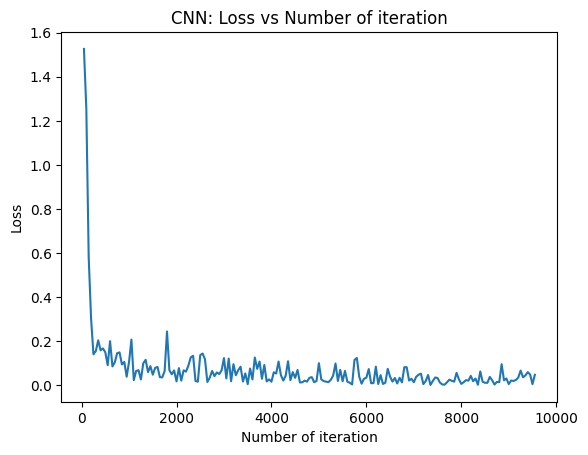

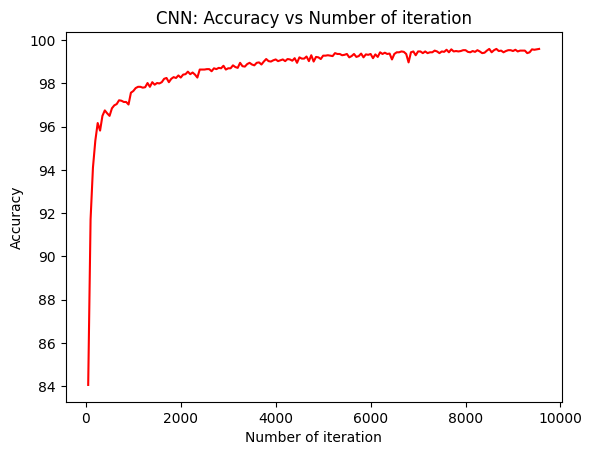

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**

**CNN 모델 해석**

**1. Loss 시각화 해석**

초기 손실값이 약 1.5로 시작했다.

1000 iteration 이내에서 0.2 이하로 빠르게 떨어지는데 CNN이 숫자 이미지의 저차원 특징(선, 곡선, 점 등)을 빠르게 학습했음을 보여준다.

이후 0에 가까운 값으로 수렴하고, 약간의 진동(배치 학습 노이즈)은 있으나 전반적으로 안정적인 패턴을 보여준다.

결과적으로 CNN은 빠르고 안정적인 손실 감소를 보이며 학습이 잘 진행됐다.

**2. Accuracy 곡선 해석**

초기 정확도가 약 84%에서 시작했다.

1000 iteration 전후에 96% 이상에 도달하고, 이후 98~99%까지 꾸준히 증가하며 거의 완벽한 분류 정확도에 근접했다.

결과적으로 CNN은 ANN보다 더 빠르게 높은 정확도에 도달했고, 장기적으로 더 안정적이고 높은 성능을 달성했다.

---
**-->**
CNN은 MNIST 데이터셋 분류에 ANN 대비 빠른 학습과 더 높은 최종 성능을 보여주었다.

---

**1. ANN (Artificial Neural Network, 인공 신경망)**

구조: 입력층 → 은닉층 → 출력층

특징:

주로 1차원 데이터를 처리하는 데 적합하다.

데이터의 모든 입력을 한꺼번에 고려하여 특징을 학습하기 때문에 이미지의 공간적 관계를 파악하기는 어렵다.



**2. CNN (Convolutional Neural Network, 합성곱 신경망)**

구조: 입력층 → 합성곱층 → 풀링층 → 완전연결층 → 출력층

특징:

합성곱층을 이용한 연산을 통해 이미지의 국소적인 특징을 계산한다.

다차원 배열 데이터를 처리하도록 구상되어 컬러 이미지와 같은 다차원 배열 처리에 특화되어 있다.

---
**-->**
결론적으로,
0-4의 MNIST처럼 간단한 데이터셋에서는 ANN도 충분히 높은 정확도를 보이지만, CNN은 이미지 처리에 특화되었기 때문에 더 빠르게, 더 높은 성능으로 수렴하게 된다고 볼 수 있다.
